# Анализ моих финансов за год (03.2025 - 03.2026)

**Цель анализа**: найти инсайты по расходам для дальнейшей их оптимизации.

### 1. Добавляем таблицу расходов из excel-файла

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from IPython.display import display, Markdown

file_path = './finance-2025.xlsx'

df = pd.read_excel(file_path)

C:\Users\proph\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


#### 1.1. Смотрим основную инфу по таблице

In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2197 entries, 0 to 2196
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Дата операции                 2197 non-null   datetime64[ns]
 1   Дата платежа                  2181 non-null   datetime64[ns]
 2   Номер карты                   1883 non-null   object        
 3   Статус                        2197 non-null   object        
 4   Сумма операции                2197 non-null   float64       
 5   Валюта операции               2197 non-null   object        
 6   Сумма платежа                 2197 non-null   float64       
 7   Валюта платежа                2197 non-null   object        
 8   Кэшбэк                        598 non-null    float64       
 9   Категория                     2197 non-null   object        
 10  MCC                           1055 non-null   float64       
 11  Описание                      

#### 1.2. Убираем ненужные столбцы, переименовываем нужные

In [58]:
df.drop(['Дата платежа', 'Номер карты', 'Валюта операции', 'Валюта платежа', 'Сумма операции с округлением'], axis=1, inplace=True)


KeyError: "['Дата платежа', 'Номер карты', 'Валюта операции', 'Валюта платежа', 'Сумма операции с округлением'] not found in axis"

In [59]:
df.columns = (['tr_date', 'status', 'tr_amount', 'payment_amount', 'cashback', 'category', 'mcc', 'description', 'bonuses', 'round_up'])

ValueError: Length mismatch: Expected axis has 16 elements, new values have 10 elements

#### 1.3. Проверяем, какие статусы есть у трансакций, оставляем только успешные

In [5]:
df['status'].unique()

array(['OK', 'FAILED'], dtype=object)

In [6]:
df = df[df['status'] == 'OK'].copy()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2194 entries, 0 to 2196
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   tr_date         2194 non-null   datetime64[ns]
 1   status          2194 non-null   object        
 2   tr_amount       2194 non-null   float64       
 3   payment_amount  2194 non-null   float64       
 4   cashback        598 non-null    float64       
 5   category        2194 non-null   object        
 6   mcc             1055 non-null   float64       
 7   description     2194 non-null   object        
 8   bonuses         2194 non-null   float64       
 9   round_up        2194 non-null   float64       
dtypes: datetime64[ns](1), float64(6), object(3)
memory usage: 188.5+ KB


In [8]:
df = df.sort_values('tr_date', ascending = True)

#### 1.4. Ищем самые частые операции

In [9]:
print(df['category'].value_counts())

category
Переводы              1057
Супермаркеты           527
Транспорт              120
Фастфуд                 95
Другое                  39
Аптеки                  30
ЖКХ                     29
Такси                   25
Мобильная связь         23
Цифровые товары         20
Заправки                20
Связь                   15
Сервис                  14
Красота                 13
Бонусы                  13
Автоуслуги              12
Медицина                12
Проценты                12
Образование             11
Наличные                11
Животные                10
Различные товары        10
Маркетплейсы             9
Книги и канцтовары       8
Ремонт и мебель          8
Лотереи                  7
Местный транспорт        6
Госуслуги                5
Финансы                  5
Цветы                    5
Рестораны                5
Развлечения              4
Экосистема Яндекс        3
Одежда и обувь           2
Канцтовары               2
Различные услуги         2
Пополнения         

#### 1.5. Отфильтруем переводы - уберем из выборки транзакции "Между своими счетами", потому что они не несут никакой полезной информации

In [10]:
df = df[df['description'] != 'Между своими счетами']

#### 1.6. Убираем из таблицы поступления, оставляем только расходы (по модулю). Также добавлям столбцы с детализацией дат операций

In [61]:
df['is_expense'] = df['tr_amount'] < 0

df = df[df['is_expense'] == True].copy()
df['expense_abs'] = df['tr_amount'].abs()

df['month'] = df['tr_date'].dt.month_name() # столбец с месяцем
df['weekday'] = df['tr_date'].dt.day_name() # столбец с названием дня недели
df['hour'] = df['tr_date'].dt.hour # столбец с часом



#### 1.7. Здесь для тренировки создадим SQL-запрос для ранжирования категорий расходов по объему трат

In [13]:
from sqlalchemy import create_engine

In [14]:
engine = create_engine('sqlite:///my-finance-analysis.db')
df.to_sql('my_finance_analysis', engine, if_exists='replace', index=False)

1243

In [15]:
query = """
SELECT
    category,
    SUM(expense_abs) as total_spent
FROM my_finance_analysis
GROUP BY category
ORDER BY total_spent DESC
"""

top_categories = pd.read_sql(query, engine)
print(top_categories)
    

              category  total_spent
0             Переводы   1427316.00
1             Наличные    405000.00
2         Супермаркеты    339718.93
3           Автоуслуги    239570.67
4              Фастфуд     76231.92
5      Ремонт и мебель     55614.00
6             Заправки     45007.49
7          Образование     42900.00
8             Медицина     40434.00
9               Другое     38729.67
10             Красота     38324.00
11     Цифровые товары     27957.02
12                 ЖКХ     22116.58
13              Аптеки     19639.03
14           Рестораны     18293.00
15        Маркетплейсы     17961.00
16               Цветы     16690.00
17               Связь     15000.00
18               Такси     14404.00
19              Сервис     13657.00
20            Животные     12915.00
21      Одежда и обувь     11912.00
22             Финансы      7976.00
23           Транспорт      5322.00
24             Лотереи      5300.00
25     Мобильная связь      4792.00
26           Госуслуги      

#### 1.8. Посмотрим расходы по месяцам

In [16]:
months_order = ['March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December', 'January', 'February']

df['month'] = pd.Categorical(df['month'], categories=months_order, ordered=True)

month_expenses = df.groupby('month', observed=True)['expense_abs'].sum()

In [17]:
print(month_expenses)

month
March        248934.46
April        106691.25
May           98433.89
June         116228.29
July         241258.19
August        97802.07
September     63170.63
October      872621.22
November     116726.61
December     460037.65
January      306966.87
February     254296.18
Name: expense_abs, dtype: float64


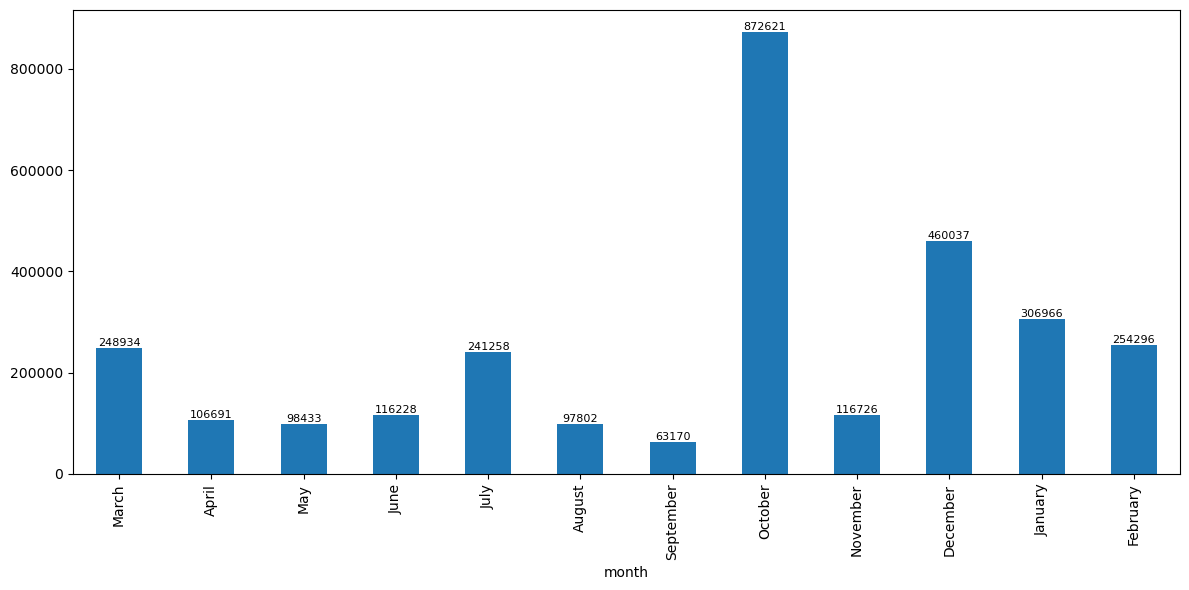

In [66]:
month_e = month_expenses.plot(kind='bar', figsize=(12,6))
month_e.bar_label(month_e.containers[0], fmt='%d', fontsize=8)
plt.tight_layout()
plt.show()

#### 1.9. Далее посмотрим расходы по дням недели

In [19]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df['weekday'] = pd.Categorical(df['weekday'], categories=weekday_order, ordered=True)

weekday_spent = df.groupby('weekday', observed=True)['expense_abs'].sum()

In [20]:
print(weekday_spent)

weekday
Monday       567928.66
Tuesday      557725.22
Wednesday    329222.26
Thursday     270403.88
Friday       350865.78
Saturday     803176.87
Sunday       103844.64
Name: expense_abs, dtype: float64


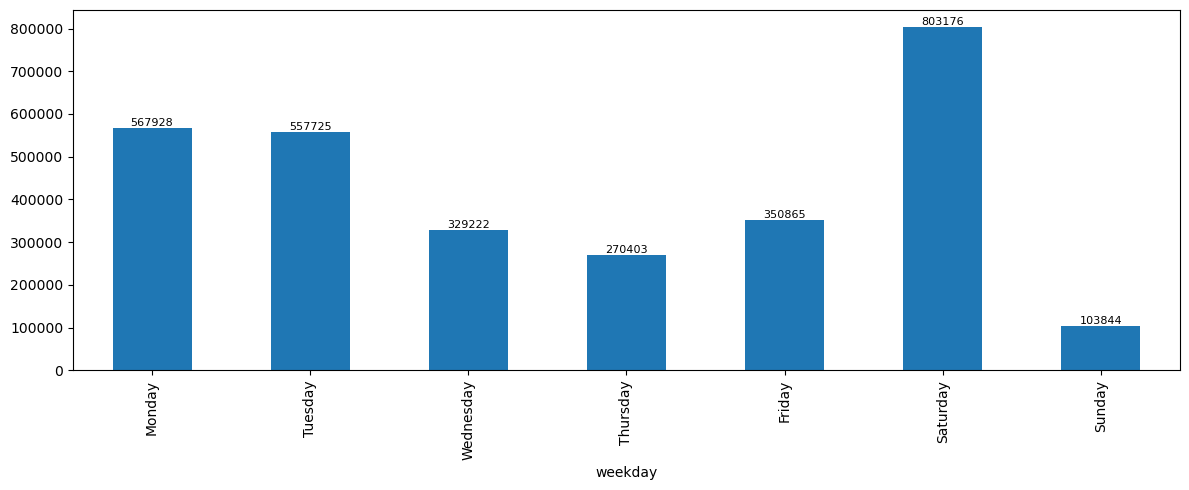

In [65]:
week_e = weekday_spent.plot(kind='bar', figsize=(12,5))
week_e.bar_label(week_e.containers[0], fmt='%d', fontsize=8)
plt.tight_layout()
plt.show()

#### 1.10 Дальше будет интересно посмотреть, как отличаются расходы в будни (по объему и структуре) от расходов в выходные 

In [22]:
df['day_type'] = df['weekday'].apply(lambda x: 'Выходной' if x in ['Saturday', 'Sunday'] else 'Рабочий день')

workday_total = df[df['day_type'] == 'Рабочий день']['expense_abs'].sum()
weekend_total = df[df['day_type'] == 'Выходной']['expense_abs'].sum()

print("=" * 40)
print("РАСХОДЫ: БУДНИ И ВЫХОДНЫЕ ДНИ")
print("=" * 40)
print(f"В рабочие дни я трачу:  {workday_total:_.0f} ₽".replace('_', ' '))
print(f"В выходные дни я трачу:   {weekend_total:_.0f} ₽".replace('_', ' '))
print(f"Разница: {weekend_total - workday_total:_.0f} ₽".replace('_', ' '))
print()

РАСХОДЫ: БУДНИ И ВЫХОДНЫЕ ДНИ
В рабочие дни я трачу:  2 076 146 ₽
В выходные дни я трачу:   907 022 ₽
Разница: -1 169 124 ₽



In [23]:
print("\nРАСХОДЫ В БУДНИ:\n")
workday_cats = df[df['day_type'] == 'Рабочий день'].groupby('category')['expense_abs'].sum().sort_values(ascending=False).head(10)
for cat, expense in workday_cats.items():
    print(f"{cat}: {expense:_.0f} ₽".replace('_', ' '))

print("\nРАСХОДЫ В ВЫХОДНЫЕ:\n")
# На что трачу в выходные (топ-5)
weekend_cats = df[df['day_type'] == 'Выходной'].groupby('category')['expense_abs'].sum().sort_values(ascending=False).head(10)
for cat, expense in weekend_cats.items():
    print(f"{cat}: {expense:_.0f} ₽".replace('_', ' '))


РАСХОДЫ В БУДНИ:

Переводы: 749 757 ₽
Наличные: 403 500 ₽
Супермаркеты: 277 468 ₽
Автоуслуги: 239 571 ₽
Ремонт и мебель: 54 865 ₽
Фастфуд: 48 457 ₽
Медицина: 40 434 ₽
Заправки: 36 868 ₽
Другое: 27 469 ₽
Образование: 27 300 ₽

РАСХОДЫ В ВЫХОДНЫЕ:

Переводы: 677 559 ₽
Супермаркеты: 62 251 ₽
Фастфуд: 27 775 ₽
Красота: 25 920 ₽
Образование: 15 600 ₽
Другое: 11 260 ₽
Цветы: 11 240 ₽
Маркетплейсы: 10 594 ₽
Рестораны: 8 750 ₽
Цифровые товары: 8 365 ₽


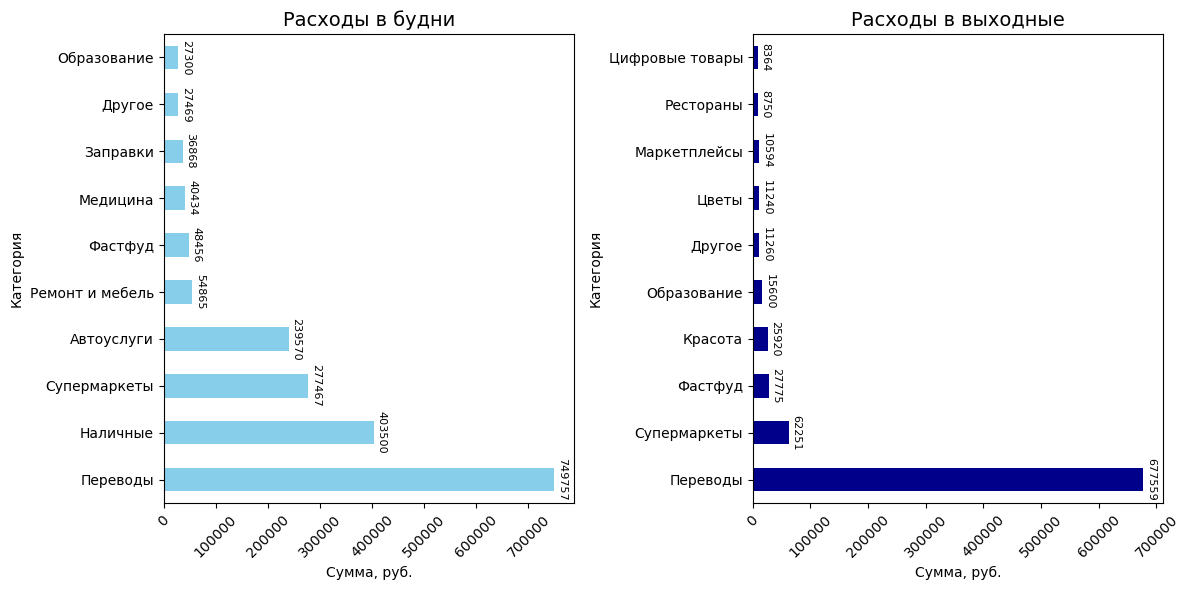

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

bars1 = workday_cats.plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Расходы в будни', fontsize=14)
axes[0].set_xlabel('Сумма, руб.')
axes[0].set_ylabel('Категория')
axes[0].tick_params(axis='x', rotation=45)
axes[0].bar_label(bars1.containers[0], fmt='%d', padding=2, fontsize=8, rotation=-90)

# Выходные
bars2 = weekend_cats.plot(kind='barh', ax=axes[1], color='darkblue')
axes[1].set_title('Расходы в выходные', fontsize=14)
axes[1].set_xlabel('Сумма, руб.')
axes[1].set_ylabel('Категория')
axes[1].tick_params(axis='x', rotation=45)
axes[1].bar_label(bars2.containers[0], fmt='%d', padding=2, fontsize=8, rotation=-90)

plt.tight_layout()
plt.savefig('workday-wekend.png')
plt.show()

### 1.11. Далее посчитаем средний чек по категориям расходов

In [26]:
avg_check = df.groupby('category')['expense_abs'].mean().round(2).sort_values(ascending=False)
print(avg_check)

category
Наличные              36818.18
Автоуслуги            19964.22
Переводы              10122.81
Ремонт и мебель        6951.75
Одежда и обувь         5956.00
Образование            3900.00
Рестораны              3658.60
Медицина               3369.50
Цветы                  3338.00
Красота                2948.00
Заправки               2250.37
Маркетплейсы           1995.67
Кино                   1830.00
Финансы                1595.20
Цифровые товары        1397.85
Животные               1291.50
Другое                 1106.56
Различные услуги       1014.00
Связь                  1000.00
Сервис                  975.50
Госуслуги               851.00
Фастфуд                 819.70
ЖКХ                     762.64
Лотереи                 757.14
Развлечения             750.00
Аптеки                  654.63
Супермаркеты            645.85
Такси                   576.16
Экосистема Яндекс       517.67
Книги и канцтовары      421.62
Различные товары        373.33
Мобильная связь         208.35

**Уберем из анализа снятие наличных**:

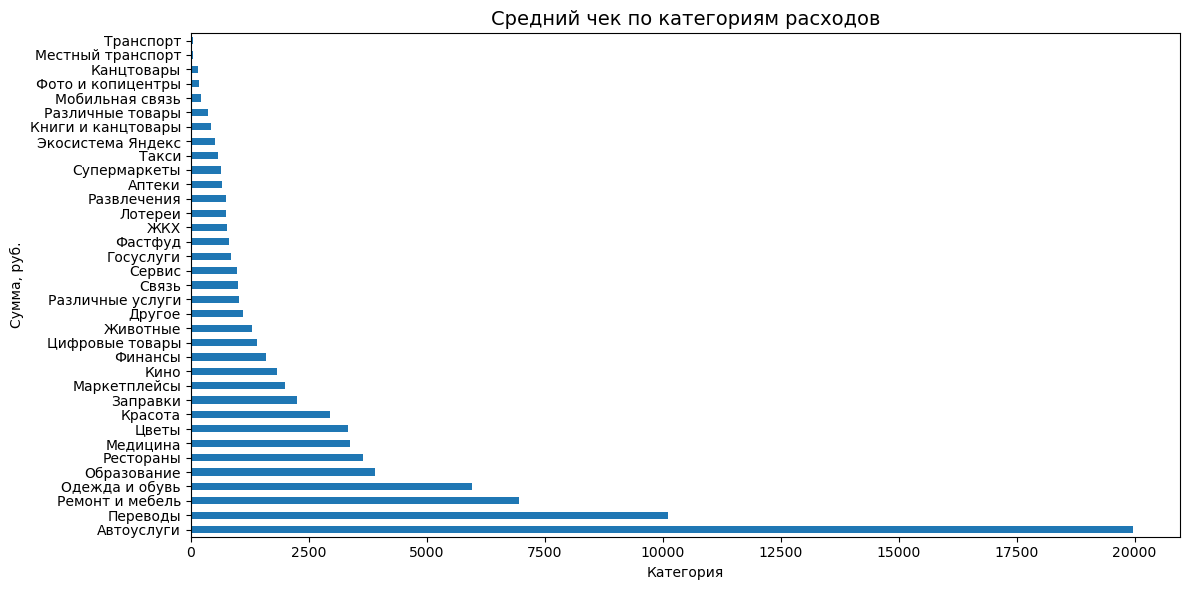

In [27]:
exclude_cat = 'Наличные'
avg_check = avg_check.drop(exclude_cat, errors='ignore')

avg_check.plot(kind='barh', figsize=(12,6))
plt.title('Средний чек по категориям расходов', fontsize=14)
plt.xlabel('Категория')
plt.ylabel('Сумма, руб.')
plt.tight_layout()
plt.savefig('avg_check.png')
plt.show()

#### 1.12. Далее посмотрим на самые большие расходы более детально

In [73]:
print("Топ-20 самых дорогих операций по категориям:\n")
drop_category = ['Переводы', 'Наличные']
top_20 = df[~df['category'].isin(drop_category)].nlargest(20, 'expense_abs')[['tr_date', 'category', 'description', 'expense_abs']]
for i, row in top_20.iterrows():
    print(f"{row['tr_date'].strftime('%d.%m.%Y')}: {row['category']} - {row['expense_abs']:,.0f} руб.")

Топ-20 самых дорогих операций по категориям:

05.03.2025: Автоуслуги - 96,730 руб.
03.07.2025: Автоуслуги - 34,390 руб.
03.07.2025: Автоуслуги - 26,000 руб.
21.03.2025: Ремонт и мебель - 24,999 руб.
31.07.2025: Автоуслуги - 23,757 руб.
07.05.2025: Автоуслуги - 22,870 руб.
05.07.2025: Красота - 17,137 руб.
26.02.2026: Автоуслуги - 14,732 руб.
09.07.2025: Автоуслуги - 14,570 руб.
22.10.2025: Ремонт и мебель - 12,399 руб.
16.07.2025: Ремонт и мебель - 10,799 руб.
09.04.2025: Сервис - 9,498 руб.
31.01.2026: Рестораны - 8,750 руб.
30.12.2025: Цифровые товары - 8,223 руб.
13.02.2026: Одежда и обувь - 7,692 руб.
24.08.2025: Финансы - 5,985 руб.
30.12.2025: Цифровые товары - 5,807 руб.
04.08.2025: Медицина - 5,700 руб.
21.02.2026: Красота - 5,680 руб.
25.12.2025: Красота - 5,000 руб.


### 2. Наибольший интерес представляют транспортные расходы (поскольку здесь есть альтернатива "автомобиль-автобус" и необязательные расходы, поскольку они наиболее гибкие

 #### 2.1. Сначала посмотрим транспортные расходы

Транспортные расходы:
  Всего потрачено: 304,653 ₽
  Количество поездок/операций: 183
  Средний чек: 1665 ₽

Детализация по видам транспорта:
                         sum  count      mean
category                                     
Автоуслуги         239570.67     12  19964.22
Заправки            45007.49     20   2250.37
Местный транспорт     349.00      6     58.17
Такси               14404.00     25    576.16
Транспорт            5322.00    120     44.35



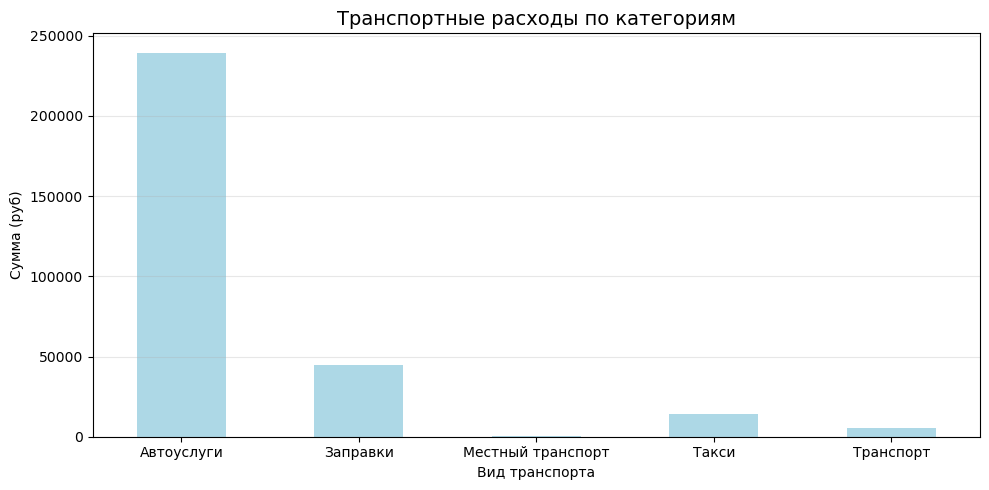

In [74]:
transport_categories = ['Такси', 'Транспорт', 'Автоуслуги', 'Заправки', 'Местный транспорт']
transport_expenses = df[df['category'].isin(transport_categories)]

print("Транспортные расходы:")
print(f"  Всего потрачено: {transport_expenses['expense_abs'].sum():,.0f} ₽")
print(f"  Количество поездок/операций: {len(transport_expenses)}")
print(f"  Средний чек: {transport_expenses['expense_abs'].mean():.0f} ₽")
print()

transport_by_type = transport_expenses.groupby('category')['expense_abs'].agg(['sum', 'count', 'mean'])
print("Детализация по видам транспорта:")
print(transport_by_type.round(2))
print()

plt.figure(figsize=(10, 5))
transport_by_type['sum'].plot(kind='bar', color='lightblue')
plt.title('Транспортные расходы по категориям', fontsize=14)
plt.xlabel('Вид транспорта')
plt.ylabel('Сумма (руб)')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('transport.png')
plt.show()



#### 2.2. Затем посмотрим необязательные расходы

Необязательные расходы:
  Всего потрачено: 154,369 ₽
  Количество операций: 121
  Средний чек: 1276 ₽

Детализация расходов:
                  sum  count    mean
category                            
Кино          1830.00      1  1830.0
Красота      38324.00     13  2948.0
Развлечения   3000.00      4   750.0
Рестораны    18293.00      5  3658.6
Фастфуд      76231.92     93   819.7
Цветы        16690.00      5  3338.0



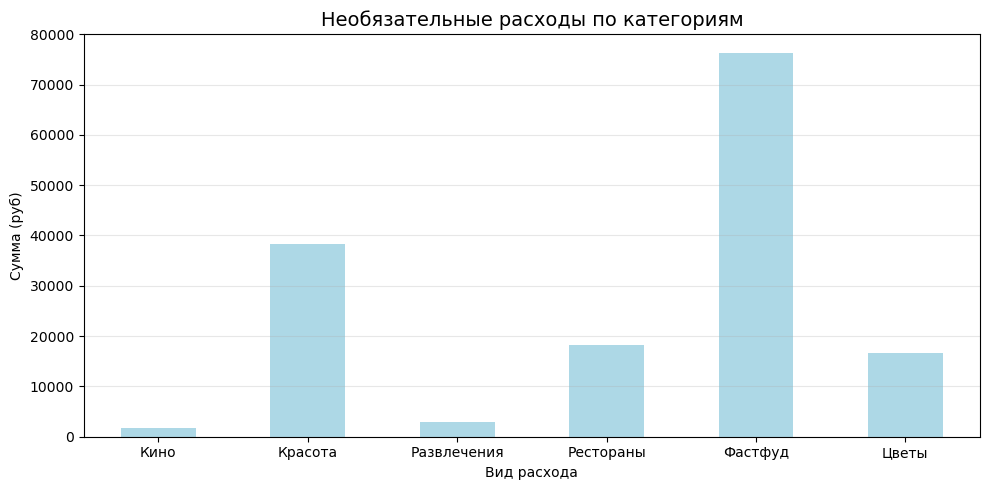

In [55]:
entertainment_categories = ['Рестораны', 'Цветы', 'Красота', 'Кино', 'Фастфуд', 'Развлечения', 'Книги и канцтовары']
entertainment_expenses = df[df['category'].isin(entertainment_categories)]

print("Необязательные расходы:")
print(f"  Всего потрачено: {entertainment_expenses['expense_abs'].sum():,.0f} ₽")
print(f"  Количество операций: {len(entertainment_expenses)}")
print(f"  Средний чек: {entertainment_expenses['expense_abs'].mean():.0f} ₽")
print()

entertainment_by_type = entertainment_expenses.groupby('category')['expense_abs'].agg(['sum', 'count', 'mean'])
print("Детализация расходов:")
print(entertainment_by_type.round(2))
print()

plt.figure(figsize=(10, 5))
entertainment_by_type['sum'].plot(kind='bar', color='lightblue')
plt.title('Необязательные расходы по категориям', fontsize=14)
plt.xlabel('Вид расхода')
plt.ylabel('Сумма (руб)')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('entertainment.png')
plt.show()


#### 2.3. Переходим к самым частым операциям

САМЫЕ ЧАСТЫЕ ОПЕРАЦИИ:
  Магнит - 172 раз(а)
  Башавтотранс - 113 раз(а)
  Пятёрочка - 99 раз(а)
  everyday - 90 раз(а)
  Брауни - 41 раз(а)
  Md.*IP Garifullina E R - 32 раз(а)
  Вендинговый автомат - 31 раз(а)
  Малинка, сеть мини-маркетов - 27 раз(а)
  Kuedmyasoufa37 - 25 раз(а)
  Яндекс Такси - 25 раз(а)
  Яндекс Еда - 21 раз(а)
  Живика - 20 раз(а)
  Мобильная карта - 19 раз(а)
  Doma_40911 - 12 раз(а)
  МТС +7 987 589-94-82 - 12 раз(а)
  Уфанет - 12 раз(а)
  Подписка Pro - 12 раз(а)
  ЭСК Башкортостана - 11 раз(а)
  Главпивторг - 11 раз(а)
  Hexlet - 11 раз(а)
  Яндекс Сервисы - 11 раз(а)
  ИП Бубенин Александр Валерьевич - 10 раз(а)
  Т-Мобайл +7 927 934-09-80 - 10 раз(а)
  Роснефть - 9 раз(а)
  АО «НСПК» - 9 раз(а)
  ДомИкс - 9 раз(а)
  Don Baton_2 - 8 раз(а)
  Красное и белое - 8 раз(а)
  UFAOIL - 8 раз(а)
  Steam - 7 раз(а)


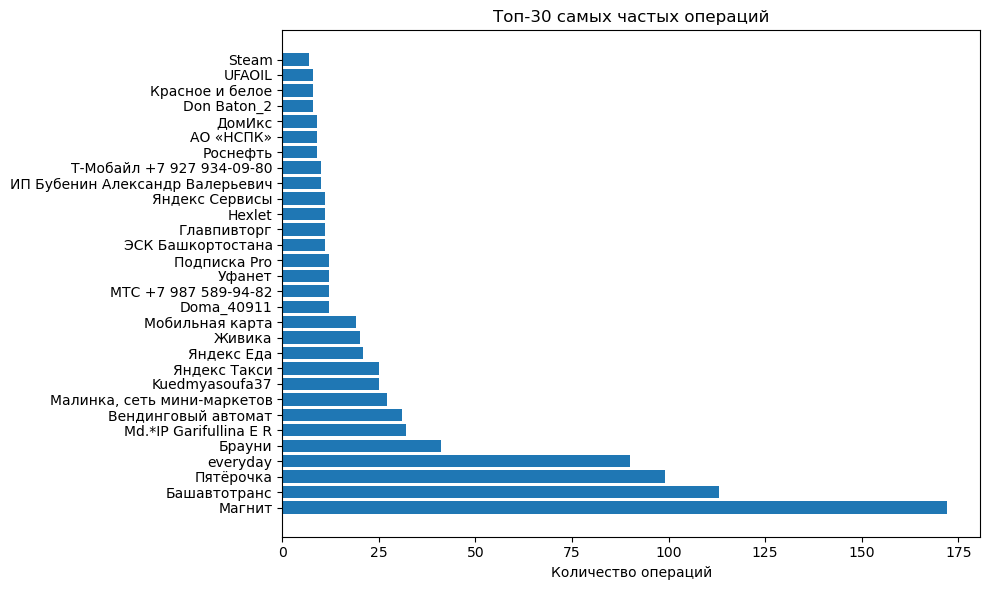

In [30]:
top_actions = df[df['category'] != 'Переводы']['description'].value_counts().head(30)

print("САМЫЕ ЧАСТЫЕ ОПЕРАЦИИ:")
for place, count in top_actions.items():
    print(f"  {place[:40]} - {count} раз(а)")

plt.figure(figsize=(10,6))
plt.barh(y=top_actions.index, width=top_actions.values)
plt.xlabel('Количество операций')
plt.title('Топ-30 самых частых операций')
plt.tight_layout()
plt.show()

#### 2.4.В конце посмотрим на топ расходов по дням недели

In [52]:
result = []

for day in weekday_order:
    top3_by_day = df[(df['weekday'] == day) & (~df['category'].isin(['Переводы', 'Наличные']))].groupby('category')['expense_abs'].sum().sort_values(ascending=False).head(3)

    print(f"\n {day}:")
    for i, (category, expense) in enumerate(top3_by_day.items(), 1):
        print(f"  {i}. {category}: {expense:_.0f} ₽".replace('_', ' '))


 Monday:
  1. Супермаркеты: 39 923 ₽
  2. Медицина: 11 500 ₽
  3. Фастфуд: 9 501 ₽

 Tuesday:
  1. Супермаркеты: 46 366 ₽
  2. Цифровые товары: 15 227 ₽
  3. Фастфуд: 8 014 ₽

 Wednesday:
  1. Автоуслуги: 137 797 ₽
  2. Супермаркеты: 58 264 ₽
  3. Ремонт и мебель: 24 897 ₽

 Thursday:
  1. Автоуслуги: 98 879 ₽
  2. Супермаркеты: 43 840 ₽
  3. Медицина: 12 832 ₽

 Friday:
  1. Супермаркеты: 89 074 ₽
  2. Ремонт и мебель: 29 498 ₽
  3. Фастфуд: 18 555 ₽

 Saturday:
  1. Супермаркеты: 28 761 ₽
  2. Красота: 25 777 ₽
  3. Фастфуд: 22 326 ₽

 Sunday:
  1. Супермаркеты: 33 491 ₽
  2. Образование: 11 700 ₽
  3. Финансы: 5 985 ₽
